In [1]:
# Import plotting, array, and table tools.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Import Scarf to open the prepared store and score its cells.
import scarf

# Keep warnings visible while hiding routine progress messages.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared pancreas store and its saved analysis.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
# Open the store so scoring can save its results.
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
# Reuse the saved analysis and its selected cells.
analysis_run = ds.pipeline.open(label="docs_default")
# Inspect the opened assays and their dimensions.
ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'clusters', 'clusters_coarse'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'highly_variable_genes', 
            'nCells'

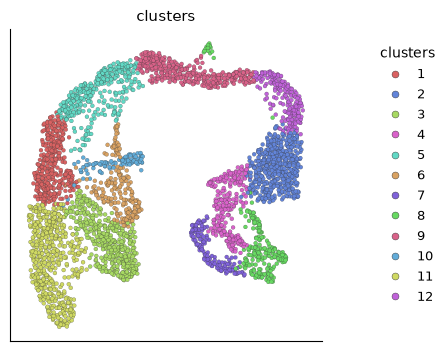

In [2]:
# Locate the saved pancreas clusters before scoring.
ds.plots.embedding(run=analysis_run, color_by="clusters")

In [3]:
# Score S and G2M programs in the saved analysis cells.
cell_cycle_ref = ds.run_cell_cycle_scoring(analysis_run["analysis_cell_selection"])
# Open the saved scores and phase assignments.
cell_cycle_values = ds.load_artifact(cell_cycle_ref)
# Read each selected cell's S-phase score.
s_score = np.asarray(cell_cycle_values["s_score"][:])
# Read each selected cell's G2M-phase score.
g2m_score = np.asarray(cell_cycle_values["g2m_score"][:])
# Read phase labels in the same cell order as the scores.
phase = np.asarray(cell_cycle_values["phase"][:]).astype(str)
# Preview the two scores alongside each cell's assigned phase.
pd.DataFrame({"S score": s_score, "G2M score": g2m_score, "phase": phase}).head()

,S score,G2M score,phase
0,-0.024501,-0.040976,G1
1,0.020201,-0.035924,S
2,-0.001931,-0.044457,G1
3,0.104609,0.018123,S
4,-0.006316,-0.035153,G1


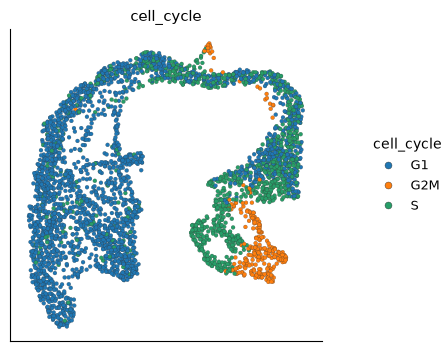

In [4]:
# Color the saved UMAP by each cell's assigned phase.
ds.plots.embedding(layout=analysis_run["umap"], color_by=cell_cycle_ref)

In [5]:
# Compare phase fractions within each saved cluster.
pd.crosstab(analysis_run.cells.fetch("clusters"), phase, normalize="index")

col_0,G1,G2M,S
row_0,,,
1,0.912807,0.000000,0.087193
2,0.410156,0.005859,0.583984
3,0.934924,0.000000,0.065076
4,0.110169,0.067797,0.822034
5,0.825215,0.005731,0.169054
6,0.924623,0.000000,0.075377
7,0.000000,0.110345,0.889655
8,0.000000,0.977477,0.022523
9,0.498674,0.007958,0.493369


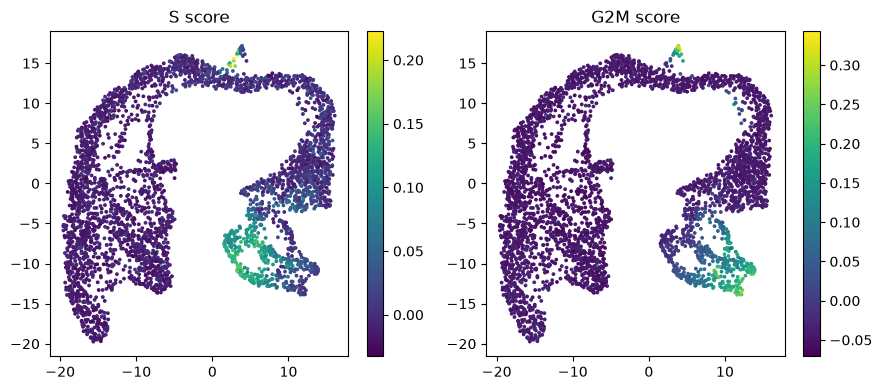

In [6]:
# Read UMAP coordinates in the same cell order as the scores.
umap = analysis_run.cells.to_pandas_dataframe(["umap_1", "umap_2"])
# Create one panel for each cell-cycle score.
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
# Plot S and G2M scores on their respective panels.
for axis, values, title in (
    (axes[0], s_score, "S score"),
    (axes[1], g2m_score, "G2M score"),
):
    # Color each cell by this panel's phase score.
    points = axis.scatter(umap["umap_1"], umap["umap_2"], c=values, s=3)
    # Identify the phase score shown in the panel.
    axis.set_title(title)
    # Show the score scale used to color the cells.
    figure.colorbar(points, ax=axis)
# Make room for panel titles and color scales.
figure.tight_layout()
# Display the completed score comparison.
figure